In [9]:
import sys
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score # Thêm hàm tính điểm R2

# Thêm đường dẫn src
sys.path.append(os.path.abspath('../src'))

# Import để pickle hiểu được object đã lưu
from model import MLP
from layers import Dense
from activations import ReLU, Linear
from losses import MSE

# Cấu hình hiển thị
%matplotlib inline
print("Đã setup xong môi trường đánh giá!")

Đã setup xong môi trường đánh giá!


In [10]:
processed_dir = os.path.join('..', 'data', 'processed')

try:
    X_test = np.load(os.path.join(processed_dir, 'X_test.npy'))
    y_test = np.load(os.path.join(processed_dir, 'y_test.npy'))
    print(f"Đã load Test Set: {X_test.shape} mẫu.")
except FileNotFoundError:
    print("Không tìm thấy file dữ liệu.")

Đã load Test Set: (4087, 13) mẫu.


In [11]:
model_path = os.path.join('..', 'models', 'mlp_model.pkl')

if os.path.exists(model_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    print("Đã load Model thành công!")
else:
    print("Không tìm thấy file model.")

Đã load Model thành công!


In [12]:
# 1. Dự đoán
print("Đang dự đoán trên tập Test...")
y_pred = model.predict(X_test)

# 2. Tính các chỉ số đánh giá (Metrics)
# MSE (Mean Squared Error)
mse = np.mean((y_test - y_pred)**2)

# RMSE (Root Mean Squared Error) - Sai số thực tế cùng đơn vị với Target
rmse = np.sqrt(mse)

# R2 Score (Độ phù hợp của mô hình: càng gần 1 càng tốt)
r2 = r2_score(y_test, y_pred)

print("\n=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"MSE (Sai số bình phương): {mse:.4f}")
print(f"RMSE (Sai số trung bình): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# QUAN TRỌNG: Quy đổi về tiền thật
# Vì lúc trước ta chia cho 100,000, giờ ta nhân lại để biết sai bao nhiêu đô la.
real_error_usd = rmse * 100000
print(f"\Sai số trung bình bằng tiền thật: ${real_error_usd:,.2f}")

Đang dự đoán trên tập Test...

=== KẾT QUẢ ĐÁNH GIÁ ===
MSE (Sai số bình phương): 0.3015
RMSE (Sai số trung bình): 0.5491
R2 Score: 0.7795
\Sai số trung bình bằng tiền thật: $54,912.24


<>:23: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:23: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
/tmp/ipykernel_70787/1491074826.py:23: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  print(f"\Sai số trung bình bằng tiền thật: ${real_error_usd:,.2f}")


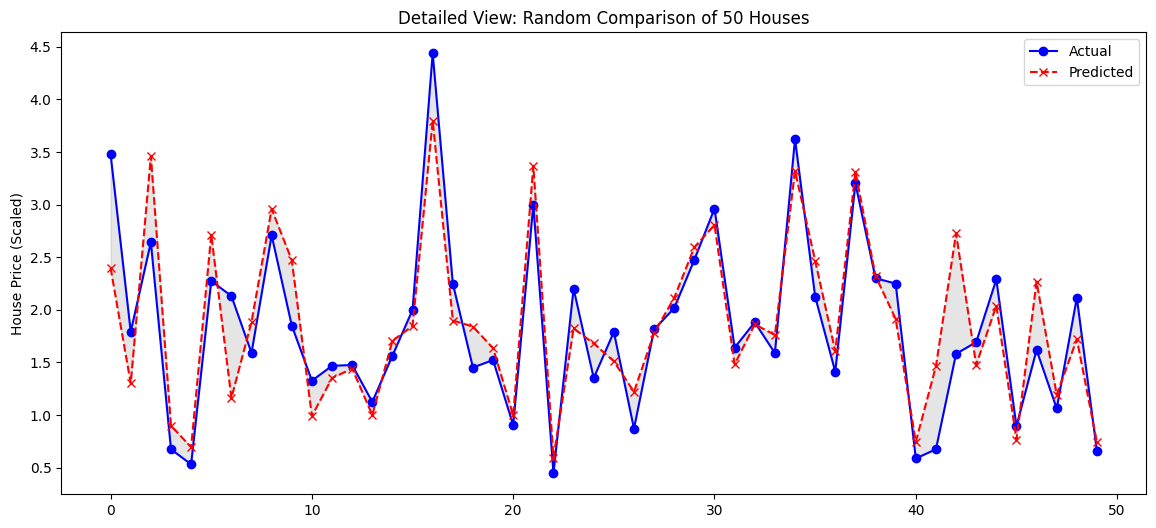

In [13]:
# Randomly select 50 samples from the Test set for detailed inspection
# Generate random indices
num_samples = 50
random_indices = np.random.choice(len(y_test), num_samples, replace=False)

# Extract data using the random indices
y_test_sample = y_test[random_indices]
y_pred_sample = y_pred[random_indices]

plt.figure(figsize=(14, 6))
# Plot the graph
plt.plot(range(num_samples), y_test_sample, label='Actual', marker='o', color='blue', linestyle='-')
plt.plot(range(num_samples), y_pred_sample, label='Predicted', marker='x', color='red', linestyle='--')

# Fill the area between the lines to highlight the deviation
plt.fill_between(range(num_samples), y_test_sample.flatten(), y_pred_sample.flatten(), color='gray', alpha=0.2)

plt.title(f"Detailed View: Random Comparison of {num_samples} Houses")
plt.ylabel("House Price (Scaled)")
plt.legend()
plt.show()

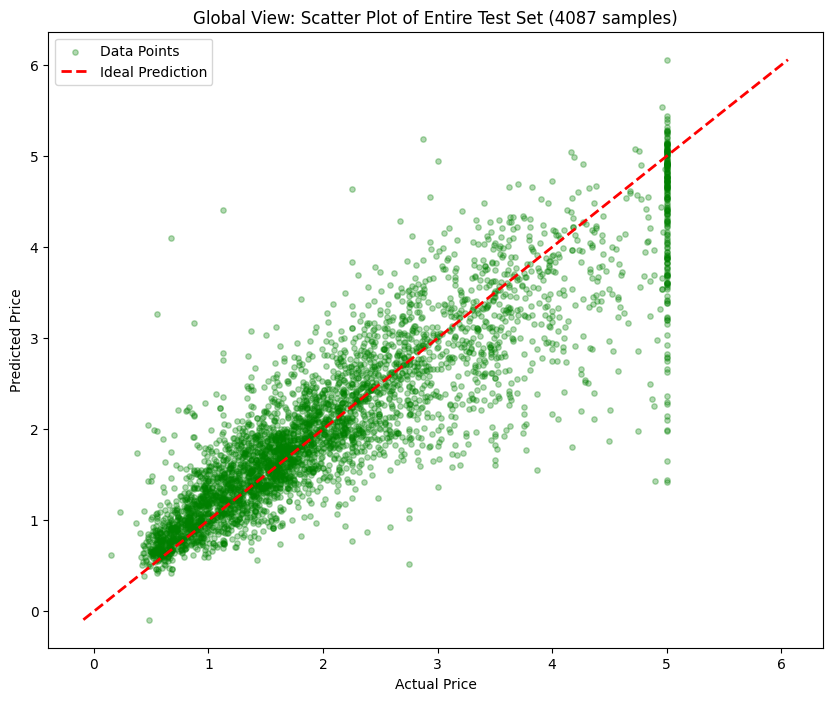

In [14]:
# Plot Scatter plot for the ENTIRE Test set
plt.figure(figsize=(10, 8))

# Use s=15 (small size) and alpha=0.3 (transparency) to visualize point density
plt.scatter(y_test, y_pred, alpha=0.3, color='green', s=15, label='Data Points')

# Ideal prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Prediction')

plt.title(f"Global View: Scatter Plot of Entire Test Set ({len(y_test)} samples)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

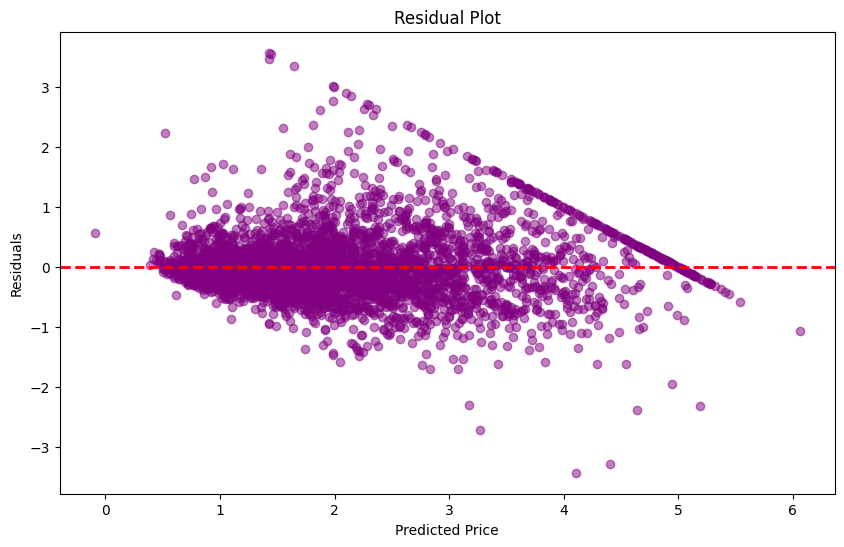

In [15]:
# Residual = Actual - Predicted
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')

# Zero error line (Ideal)
plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.show()

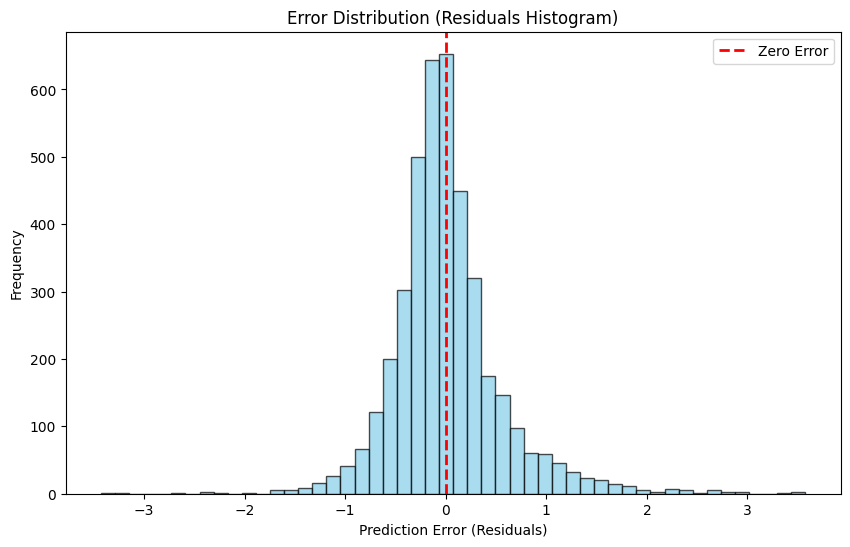

In [16]:
# Histogram of Residuals (Error Distribution)
plt.figure(figsize=(10, 6))

# Use bins=50 to create a smooth histogram
plt.hist(residuals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Add a vertical dashed line at 0 (Zero error reference)
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label='Zero Error')

plt.title("Error Distribution (Residuals Histogram)")
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


📊 --- ANALYSIS OF THE IMPACT OF CAPPED DATA (3 ARGUMENTS) ---

🔹 1. EVIDENCE: DISTORTING THE OPTIMIZATION PROCESS (GRADIENT)
   - MSE of normal group: 0.2566
   - MSE of capped group: 1.1789 (4.6x larger!)
   - Although the capped group only represents 4.9% of the data,
     it contributes 19.0% of the total error (Gradient).
   👉 Conclusion: The gradient focuses excessively on fixing this group,
      distracting the model from learning the overall distribution.


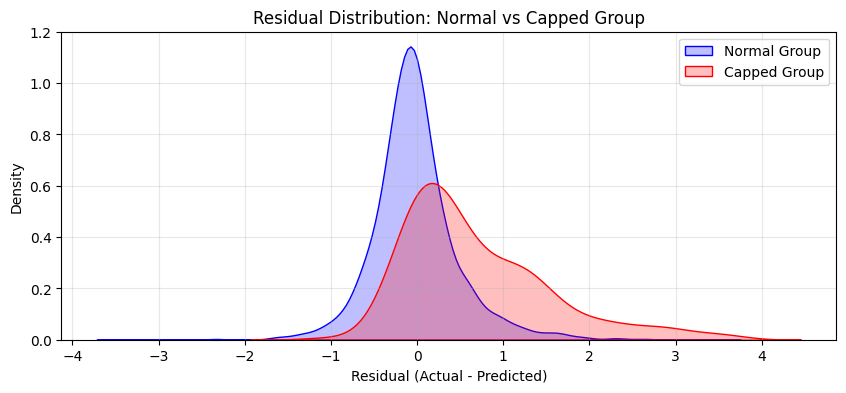


🔹 2. EVIDENCE: LOSS OF LUXURY HOUSING PREDICTION ABILITY
   - Number of houses actually at the cap (>= 5.0): 199
   - Number of houses predicted above the cap (> 5.0): 45


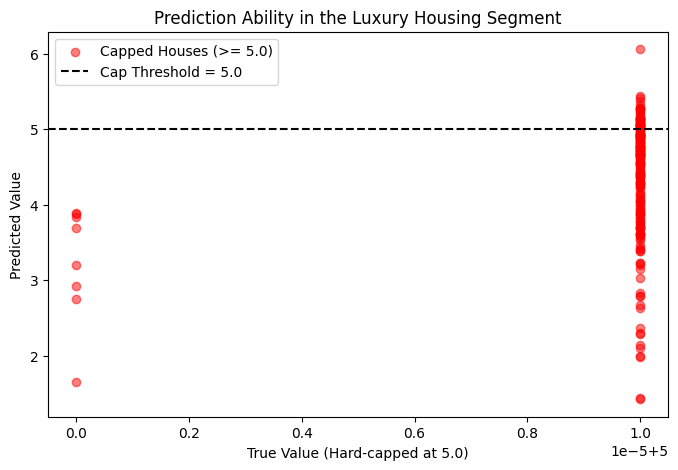

   👉 Conclusion: The red points scattered below the 5.0 line show
      that the model consistently under-predicts expensive houses.

🔹 3. EVIDENCE: FEATURE WEIGHT BIAS (ALL 5 REGIONS)
Category        | Count | Mean Error (Actual - Predicted)    
----------------------------------------------------------------------
<1H OCEAN       | 1803  | 0.0280
INLAND          | 1340  | -0.0164
ISLAND          | 2     | -2.1290
NEAR BAY        | 428   | 0.0030
NEAR OCEAN      | 514   | 0.0243


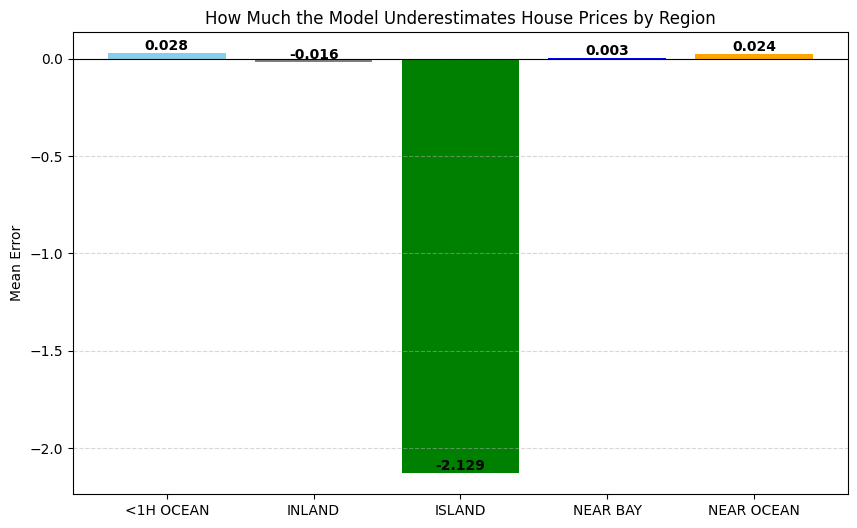


👉 FINAL OBSERVATIONS:
   - INLAND has the lowest error (close to 0),
     showing that the model learns low-price regions well.
   - Coastal regions (NEAR BAY, NEAR OCEAN) show the highest positive errors.
     -> This confirms that the closer a house is to the ocean
        (and therefore the more expensive it becomes),
        the more the model is constrained by the 500k price cap,
        leading to significant under-prediction.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
CAP_THRESHOLD = 5.0

# Note: Make sure the indices match the correct columns in X_test
# Based on your preprocessing log:
# 0-7: Numerical columns
# 8: <1H OCEAN, 9: INLAND, 10: ISLAND, 11: NEAR BAY, 12: NEAR OCEAN
IDX_INLAND = 9
IDX_NEAR_OCEAN = 12

print("\n📊 --- ANALYSIS OF THE IMPACT OF CAPPED DATA (3 ARGUMENTS) ---")

# 1. Predict again
y_pred = model.predict(X_test)

# Actual error (Positive = Model underestimates the true value)
residuals = y_test - y_pred

# Squared errors used for MSE
squared_errors = residuals ** 2

# Split groups
mask_capped = (y_test >= CAP_THRESHOLD).flatten()
mask_normal = (y_test < CAP_THRESHOLD).flatten()

# ==============================================================================
# ARGUMENT 1: DISTORTING GRADIENT DESCENT (MSE HEAVILY PENALIZES LARGE ERRORS)
# ==============================================================================
print("\n🔹 1. EVIDENCE: DISTORTING THE OPTIMIZATION PROCESS (GRADIENT)")

mse_capped = np.mean(squared_errors[mask_capped])
mse_normal = np.mean(squared_errors[mask_normal])

# Contribution ratio to total error
total_sse = np.sum(squared_errors)
capped_sse = np.sum(squared_errors[mask_capped])

percent_error_contribution = (capped_sse / total_sse) * 100
percent_data_volume = (np.sum(mask_capped) / len(y_test)) * 100

print(f"   - MSE of normal group: {mse_normal:.4f}")
print(f"   - MSE of capped group: {mse_capped:.4f} ({mse_capped/mse_normal:.1f}x larger!)")
print(f"   - Although the capped group only represents {percent_data_volume:.1f}% of the data,")
print(f"     it contributes {percent_error_contribution:.1f}% of the total error (Gradient).")

print("   👉 Conclusion: The gradient focuses excessively on fixing this group,")
print("      distracting the model from learning the overall distribution.")

# Plot residual distribution
plt.figure(figsize=(10, 4))

sns.kdeplot(
    residuals[mask_normal].flatten(),
    label='Normal Group',
    fill=True,
    color='blue'
)

sns.kdeplot(
    residuals[mask_capped].flatten(),
    label='Capped Group',
    fill=True,
    color='red'
)

plt.title("Residual Distribution: Normal vs Capped Group")
plt.xlabel("Residual (Actual - Predicted)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ==============================================================================
# ARGUMENT 2: METRICS FAIL TO REFLECT REALITY (LOSS OF LUXURY PREDICTION ABILITY)
# ==============================================================================
print("\n🔹 2. EVIDENCE: LOSS OF LUXURY HOUSING PREDICTION ABILITY")

# Count predictions above the cap
pred_above_cap = np.sum(y_pred > CAP_THRESHOLD)
true_above_cap = np.sum(y_test >= CAP_THRESHOLD)

print(f"   - Number of houses actually at the cap (>= 5.0): {true_above_cap}")
print(f"   - Number of houses predicted above the cap (> 5.0): {pred_above_cap}")

# Scatter plot for luxury segment
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test[mask_capped],
    y_pred[mask_capped],
    alpha=0.5,
    color='red',
    label='Capped Houses (>= 5.0)'
)

plt.axhline(
    y=CAP_THRESHOLD,
    color='black',
    linestyle='--',
    label='Cap Threshold = 5.0'
)

plt.xlabel("True Value (Hard-capped at 5.0)")
plt.ylabel("Predicted Value")
plt.title("Prediction Ability in the Luxury Housing Segment")
plt.legend()
plt.show()

print("   👉 Conclusion: The red points scattered below the 5.0 line show")
print("      that the model consistently under-predicts expensive houses.")

# ==============================================================================
# ARGUMENT 3: FEATURE WEIGHT BIAS (ALL 5 GEOGRAPHICAL CATEGORIES)
# ==============================================================================
print("\n🔹 3. EVIDENCE: FEATURE WEIGHT BIAS (ALL 5 REGIONS)")

# Based on pd.get_dummies column order from preprocessing:
# 8: <1H OCEAN
# 9: INLAND
# 10: ISLAND
# 11: NEAR BAY
# 12: NEAR OCEAN

categories = {
    "<1H OCEAN": 8,
    "INLAND": 9,
    "ISLAND": 10,
    "NEAR BAY": 11,
    "NEAR OCEAN": 12
}

names = []
errors = []
counts = []

print(f"{'Category':<15} | {'Count':<5} | {'Mean Error (Actual - Predicted)':<35}")
print("-" * 70)

for name, idx in categories.items():

    # Find samples belonging to this category
    # Use max value because data was scaled by StandardScaler
    active_val = np.max(X_test[:, idx])
    mask = np.isclose(X_test[:, idx], active_val)

    count = np.sum(mask)

    if count > 0:

        # Positive error = Under-prediction
        mean_error = np.mean(residuals[mask])

        names.append(name)
        errors.append(mean_error)
        counts.append(count)

        print(f"{name:<15} | {count:<5} | {mean_error:.4f}")

    else:
        print(f"{name:<15} | 0     | N/A (No samples in test set)")

# --- PLOT ---
plt.figure(figsize=(10, 6))

bars = plt.bar(
    names,
    errors,
    color=['skyblue', 'gray', 'green', 'blue', 'orange']
)

plt.axhline(0, color='black', linewidth=0.8)

plt.ylabel("Mean Error")
plt.title("How Much the Model Underestimates House Prices by Region")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add values above bars
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{yval:.3f}',
        va='bottom',
        ha='center',
        fontweight='bold'
    )

plt.show()

print("\n👉 FINAL OBSERVATIONS:")
print("   - INLAND has the lowest error (close to 0),")
print("     showing that the model learns low-price regions well.")

print("   - Coastal regions (NEAR BAY, NEAR OCEAN) show the highest positive errors.")
print("     -> This confirms that the closer a house is to the ocean")
print("        (and therefore the more expensive it becomes),")
print("        the more the model is constrained by the 500k price cap,")
print("        leading to significant under-prediction.")